<a href="https://colab.research.google.com/github/lilygracerobertson/Maths/blob/main/SCIE1500Materials/Week_3/LabFiles/Week03_Lab_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Lab: The Fishery Manager's Dilemma
**SCIE1500 — Analytical Methods for Scientists | Semester 2, 2026**

> **Lab format:** Work in your group. Discuss answers before typing code.
> **Today's session:** ~2 hours | Ask your tutor when stuck.

---
## 🌍 Scientific Scenario

![Schaefer growth curve with harvest lines and MSY point](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_3/images/W3_fishery_schaefer.svg?raw=1)

You are a scientific advisor to the **Western Australian Fisheries Authority**. The authority manages a sardine fishery showing signs of overfishing.

Marine biologists use the **Schaefer model** for sardine population growth:

$$G(S) = g \cdot S \cdot \left(1 - \frac{S}{K}\right)$$

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $g$ | 0.4 /yr | Intrinsic growth rate |
| $K$ | 1500 t | Carrying capacity |
| $S$ | 1200 t | Current stock |
| $H$ | 120 t/yr | Current harvest |

> *Is this harvest sustainable?*

---
## 🎯 Group Task & Learning Objectives

| Part | Time | You will be able to... |
|------|------|------|
| A | ~20 min | Use a Schaefer model to compute growth rates and Maximum Sustainable Yield (MSY), explaining bounded growth |
| B | ~25 min | Find equilibrium stock levels by solving a quadratic equation and interpret the stability of two equilibria for current and proposed harvest levels |
| C | ~10 min | Write a policy recommendation based on your analysis |

In [ ]:
# Run this cell first — loads libraries for today's lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## Part A: The Schaefer Model (~20 min)

Expanding the Schaefer model:
$$G(S) = 0.4S\left(1 - \frac{S}{1500}\right) = 0.4S - \frac{0.4}{1500}S^2$$

This is a **downward-opening parabola** — growth is zero at $S = 0$ and $S = K$, and peaks at $S^* = K/2$.

In [ ]:
# A.1 — Define the Schaefer growth function and evaluate at three stock levels
g = 0.4      # intrinsic growth rate
K = 1500     # carrying capacity (tonnes)

def G(S):
    'Annual population growth (tonnes/year).'
    return g * S * (1 - S / K)

for S_level in [400, 750, 1200]:
    print(f"G({S_level:4d}) = {G(S_level):.1f} tonnes/year")

S_msy = K / 2
G_msy = G(S_msy)
print(f"\nMSY at S = K/2 = {S_msy:.0f} t  →  G_max = {G_msy:.1f} t/yr")

Plot the Schaefer growth curve.

In [ ]:
# A.2 — Plot the Schaefer growth curve
S_vals = np.linspace(0, K, 400)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S_vals, G(S_vals), "steelblue", lw=2, label="Growth G(S)")
ax.plot(S_msy, G_msy, "go", ms=10, label=f"MSY: S={S_msy:.0f} t, G={G_msy:.0f} t/yr")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Stock Level S (tonnes)")
ax.set_ylabel("Growth Rate G(S) (tonnes/year)")
ax.set_title("Sardine Fishery: Schaefer Growth Model")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✏️ **Activity A — discuss as a group:**
1. Why does growth peak at $S = K/2$ rather than near the maximum stock level?
2. What does $G(K) = 0$ represent ecologically?
3. At $S = 1200$ t (above $K/2$), is growth increasing or decreasing as stock rises?

```
Answer1. Growth peaks at S = K/2 because the Schaefer model is a downward-opening parabola. At S=0 (no fish), there's no reproduction. At S=K (carrying capacity), resources are exhausted, and birth rates equal death rates, leading to zero net growth. The maximum growth rate occurs at the intermediate stock level where there is an optimal balance of reproductive capacity and available resources.
2. G(K) = 0 represents ecologically the carrying capacity. This means that at the carrying capacity (K), the population growth rate is zero, as the population has reached its maximum size that the environment can sustain, and births are balanced by deaths.
3. At S = 1200 t (which is above K/2 = 750 t), growth is decreasing as the stock rises. This is because the Schaefer growth curve is a downward-opening parabola that peaks at K/2, so for any stock level greater than K/2, the growth rate is on the declining part of the curve.
```

---
## Part B: Sustainability Analysis (~25 min)

A harvest $H$ is **sustainable** when growth replaces what is removed: $G(S) \geq H$.

Setting $G(S) = H$ gives the **equilibrium stock levels** — states where stock stays constant.

Rearranging: $\frac{g}{K}S^2 - gS + H = 0$ → solve with the quadratic formula.

In [ ]:
# B.1 — Sustainability check at current stock
S_current = 1200
H = 120    # current harvest (tonnes/year)

G_current = G(S_current)
print(f"G(1200) = {G_current:.1f} t/yr")
print(f"H       = {H} t/yr")
print(f"Sustainable? {G_current >= H}  (need G >= H)")

Equilibrium stock levels for H = 120: quadratic formula.

In [ ]:
# B.2 — Equilibrium stock levels for H = 120: quadratic formula
a_coef =  g / K
b_coef = -g
c_coef =  H

disc = b_coef**2 - 4 * a_coef * c_coef
S1 = (-b_coef - np.sqrt(disc)) / (2 * a_coef)   # lower (unstable)
S2 = (-b_coef + np.sqrt(disc)) / (2 * a_coef)   # upper (stable)

print(f"Equilibria for H = {H} t/yr:")
print(f"  S₁ = {S1:.1f} t  (lower — unstable collapse threshold)")
print(f"  S₂ = {S2:.1f} t  (upper — stable management target)")
print(f"  Current stock {S_current} t is {'above' if S_current > S1 else 'below'} collapse threshold.")

What if harvest increases to 140 t/yr?

In [ ]:
# B.3 — What if harvest increases to 140 t/yr?
H_proposed = 140

c_new = H_proposed
disc_new = b_coef**2 - 4 * a_coef * c_new
if disc_new < 0:
    print(f"H = {H_proposed} t/yr exceeds MSY — no sustainable equilibrium!")
else:
    S1_new = (-b_coef - np.sqrt(disc_new)) / (2 * a_coef)
    S2_new = (-b_coef + np.sqrt(disc_new)) / (2 * a_coef)
    print(f"Equilibria for H = {H_proposed} t/yr:")
    print(f"  S₁ = {S1_new:.1f} t  (collapse threshold rises by {S1_new - S1:.1f} t → riskier)")
    print(f"  S₂ = {S2_new:.1f} t  (stable target falls by {S2 - S2_new:.1f} t → lower stock)")


The chart below shows both scenarios.

In [ ]:
# Plot both scenarios
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_vals, G(S_vals), "steelblue", lw=2, label="Growth G(S)")
ax.axhline(H,          color="red",    ls="--", lw=1.5, label=f"Current H = {H} t/yr")
ax.axhline(H_proposed, color="orange", ls="--", lw=1.5, label=f"Proposed H = {H_proposed} t/yr")
ax.axvline(S_current,  color="gray",   ls=":",  alpha=0.6, label=f"Current stock {S_current} t")
ax.plot(S_msy, G_msy, "go", ms=8, label=f"MSY = {G_msy:.0f} t/yr")
ax.set_xlabel("Stock Level S (tonnes)")
ax.set_ylabel("Growth / Harvest (tonnes/year)")
ax.set_title("Sardine Fishery: Sustainability Analysis")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✏️ **Activity B:**
1. The current stock (1200 t) is *above* $S_2$ for $H = 120$. What happens to the stock over time?
2. Increasing harvest to 140 t/yr raises the collapse threshold. By how many tonnes?
3. The MSY is 150 t/yr. Why must harvest never exceed MSY?

```python
print("MSY =", G(K/2))
# Answers:
# 1. If the current stock (1200 t) is above the stable equilibrium S₂ (1000 t) for a harvest of 120 t/yr, the stock will gradually decrease over time. This is because at 1200 t, the population's growth rate (G(1200) = 72 t/yr) is less than the harvest rate (H = 120 t/yr). The stock will continue to decline until it reaches the stable equilibrium level of 1000 t, where growth equals harvest.
# 2. Increasing the harvest to 140 t/yr raises the collapse threshold from S₁ = 500 t (for H=120) to S₁ = 666.7 t (for H=140). This is an increase of 166.7 tonnes (666.7 - 500 = 166.7).
# 3. Harvest must never exceed MSY (Maximum Sustainable Yield) because MSY represents the absolute maximum growth rate the population can achieve. If the harvest rate is set above the MSY, there will be no stock level at which the population's growth can replenish what is being harvested. This will lead to a continuous decline in stock, inevitably resulting in the collapse or extinction of the fishery.
```

---
## Part C: Policy Recommendation (~10 min)

Write a **4–5 sentence recommendation** to the Fisheries Authority:
- Is the current 120 t/yr harvest sustainable?
- Should the proposed 140 t/yr increase be approved?
- What harvest level do you recommend for long-term stability?

```
RECOMMENDATION TO WA FISHERIES AUTHORITY:

The current harvest of 120 t/yr is not sustainable at the present stock level of 1200 t, as the population's growth rate is only 72 t/yr, leading to a net decline in stock. Therefore, the proposed increase to 140 t/yr should not be approved, as it would further accelerate this decline and bring the fishery significantly closer to its collapse threshold. For long-term stability and recovery, we recommend an immediate reduction in harvest to below 72 t/yr to allow the sardine stock to rebuild. Once the stock has recovered to optimal levels (around K/2 = 750 t), a harvest rate at or below the Maximum Sustainable Yield (MSY) of 150 t/yr could be maintained.
```

---
## ✅ Lab Wrap-Up

- [ ] Computed $G(S)$ at three stock levels and identified the MSY (Part A)
- [ ] Found equilibrium stock levels for both harvest scenarios (Part B)
- [ ] Written a policy recommendation with specific numbers (Part C)
- [ ] **Groups 3 & 4:** Opened your Presentation Brief (Lab A or Lab B) and started Part A

> 💡 **Key insight:** There are always *two* equilibria — one stable (recovery target), one unstable (collapse threshold). Higher harvest brings these closer together.


---
---
## ✅ Submission Exercise — Batch 1

**Due: Monday 11 August, 11:59 pm — submit on LMS**
**Covers: Weeks 1–3 (functions, exponential models, logistic growth)**

Submit individually. Show full mathematical working for all calculations.
Upload your **completed notebook (.ipynb)** to the LMS — do not submit screenshots.
        

In [ ]:

# Fill in your details before submitting
student_name   = "Lily Robertson"
student_number = "25286485"
print(f"Submission by: {student_name}  |  Student #{student_number}")



---
### Q1 — Functions and Rates of Change (Week 1)

Southern bluefin tuna population data:

| Year | $t$ (yrs since 2000) | $P(t)$ (thousand fish) |
|------|---------------------|------------------------|
| 2000 | 0  | 90 |
| 2005 | 5  | 82 |
| 2010 | 10 | 71 |
| 2015 | 15 | 65 |
| 2020 | 20 | 61 |

**(a)** Calculate the average rate of change of $P$ over each of the four 5-year intervals. Show working.
        


**Answer (a):**

-   **Interval 0-5 years:**  ($82 - 90$) / ($5 - 0$) = $-8 / 5 = -1.60$ thousand fish/year
-   **Interval 5-10 years:** ($71 - 82$) / ($10 - 5$) = $-11 / 5 = -2.20$ thousand fish/year
-   **Interval 10-15 years:** ($65 - 71$) / ($15 - 10$) = $-6 / 5 = -1.20$ thousand fish/year
-   **Interval 15-20 years:** ($61 - 65$) / ($20 - 15$) = $-4 / 5 = -0.80$ thousand fish/year



**(b)** Is the decline rate constant? Describe the pattern and what it implies about the shape of $P(t)$.
        


**Answer (b):**

The decline rate is not constant. The rates are -1.60, -2.20, -1.20, and -0.80 thousand fish/year. The decline initially accelerates, then slows down. This pattern suggests that the population $P(t)$ is decreasing at a slower rate over time, implying the curve is concave up and possibly stabilizing at lower levels.


**(c)** Plot $P(t)$ from $t = 0$ to $t = 20$. Does a linear model fit this data well? Explain.
        

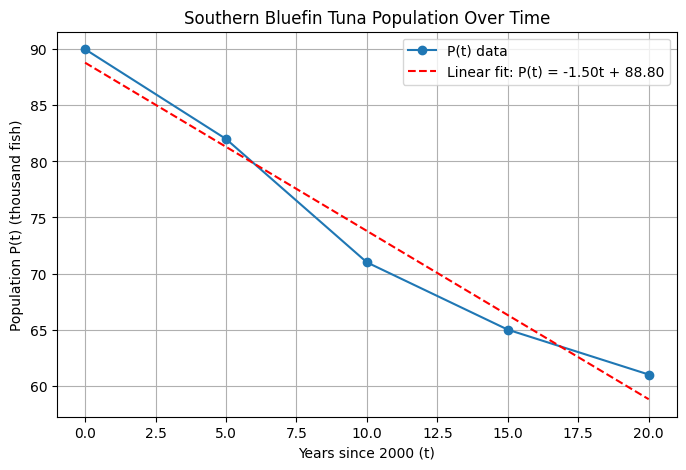

In [3]:
# Q1c — your code here
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

t_values = np.array([0, 5, 10, 15, 20])
p_values = np.array([90, 82, 71, 65, 61])

# Plot the data points
plt.figure(figsize=(8, 5))
plt.plot(t_values, p_values, 'o-', label='P(t) data')

# Perform linear regression
fit_coeffs = np.polyfit(t_values, p_values, 1) # Degree 1 for linear fit
linear_fit = np.poly1d(fit_coeffs)

# Plot the linear regression line
plt.plot(t_values, linear_fit(t_values), 'r--', label=f'Linear fit: P(t) = {fit_coeffs[0]:.2f}t + {fit_coeffs[1]:.2f}')

plt.title('Southern Bluefin Tuna Population Over Time')
plt.xlabel('Years since 2000 (t)')
plt.ylabel('Population P(t) (thousand fish)')
plt.grid(True)
plt.legend()
plt.show()

**Answer (c) — written interpretation:**

Based on the plot, a linear model does not fit the data well. While the overall trend is a decline, the data points do not fall perfectly on a straight line. The initial decline seems steeper, and then it flattens out, which aligns with our observation in part (b) that the decline rate is not constant; it accelerates and then slows down. A linear model would imply a constant rate of change, which is clearly not the case here, as evidenced by the varying average rates of change calculated previously.


---
### Q2 — Exponential Decay (Week 2)

A marine toxin degrades as $C(t) = 250\,e^{-0.08t}$ μg/L ($t$ in days).

**(a)** Find the half-life algebraically. Show working using logarithms.
        

**Answer (a)

 initial concentration is $C(0) = 250 \, \mu g/L$. So, we set $C(t) = 250 / 2 = 125 \, \mu g/L$.

Given the function: $C(t) = 250\,e^{-0.08t}$

Set $C(t) = 125$:
$125 = 250\,e^{-0.08t}$

Divide both sides by 250:
$\frac{125}{250} = e^{-0.08t}$
$0.5 = e^{-0.08t}$

Take the natural logarithm (ln) of both sides:
$\ln(0.5) = \ln(e^{-0.08t})$
$\ln(0.5) = -0.08t$

Solve for $t$:
$t = \frac{\ln(0.5)}{-0.08}$

Since $\ln(0.5) \approx -0.693$,
$t \approx \frac{-0.693}{-0.08}$
$t \approx 8.6625$

So, the half-life is approximately **8.66 days**.


**(b)** The safe-swimming threshold is 5 μg/L. Find the crossing day algebraically, then verify in Python.
        

**Answer (b) — algebraic working:**

We need to find the time $t$ when the concentration $C(t)$ reaches the safe-swimming threshold of $5 \, \mu g/L$.

Given the function: $C(t) = 250\,e^{-0.08t}$

Set $C(t) = 5$:
$5 = 250\,e^{-0.08t}$

Divide both sides by 250:
$\frac{5}{250} = e^{-0.08t}$
$0.02 = e^{-0.08t}$

Take the natural logarithm (ln) of both sides:
$\ln(0.02) = \ln(e^{-0.08t})$
$\ln(0.02) = -0.08t$

Solve for $t$:
$t = \frac{\ln(0.02)}{-0.08}$

Since $\ln(0.02) \approx -3.912$,
$t \approx \frac{-3.912}{-0.08}$
$t \approx 48.9$

So, the concentration reaches the safe-swimming threshold of 5 μg/L after approximately **48.9 days**.


**(c)** Plot $C(t)$ from $t = 0$ to $t = 60$. Mark the threshold as a horizontal dashed line and the crossing day as a vertical marker.
        

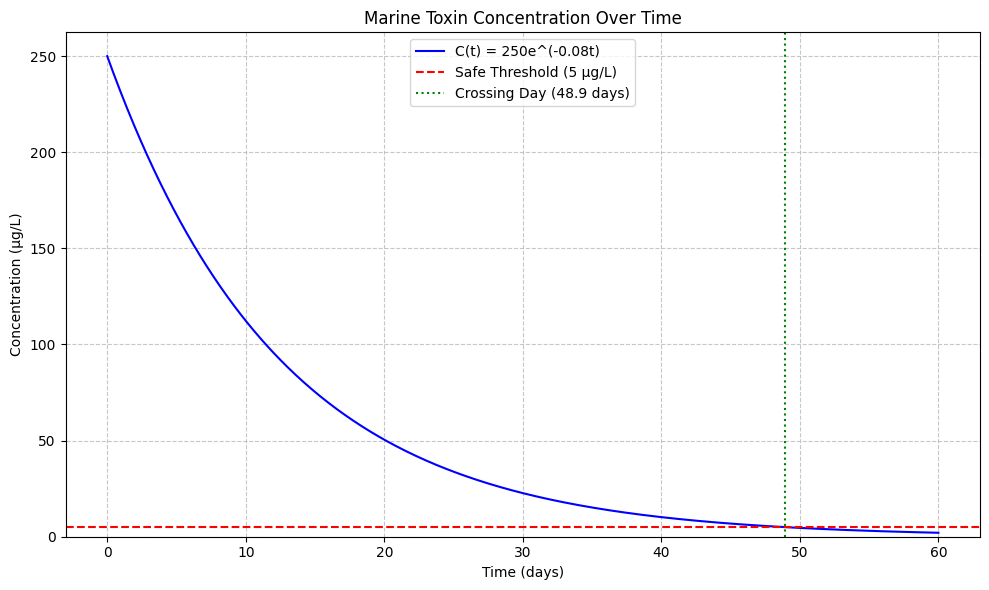

In [5]:
# Q2c — your code here
import numpy as np
import matplotlib.pyplot as plt

# Define the concentration function (if not already defined in the current session)
def C(t):
    return 250 * np.exp(-0.08 * t)

# Define the time range for plotting
t_plot = np.linspace(0, 60, 500) # From t=0 to t=60 days

# Calculate C(t) for the plotting range
c_values = C(t_plot)

# Safe-swimming threshold and crossing day (from previous calculations)
safe_threshold = 5 # μg/L
# If t_crossing was not retained in kernel, recalculate
# t_crossing = np.log(safe_threshold / 250) / -0.08

plt.figure(figsize=(10, 6))
plt.plot(t_plot, c_values, label='C(t) = 250e^(-0.08t)', color='blue')

# Mark the safe-swimming threshold
plt.axhline(y=safe_threshold, color='red', linestyle='--', label=f'Safe Threshold ({safe_threshold} μg/L)')

# Mark the crossing day with a vertical line
plt.axvline(x=t_crossing, color='green', linestyle=':', label=f'Crossing Day ({t_crossing:.1f} days)')

plt.title('Marine Toxin Concentration Over Time')
plt.xlabel('Time (days)')
plt.ylabel('Concentration (μg/L)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()


---
### Q3 — Logistic Fishery (Week 3)

A Carpentaria prawn fishery: $G(S) = 0.5S(1 - S/2000)$.

**(a)** Find the MSY and the stock level at which it occurs. Show the algebraic derivation.
        

**Answer (a):**

The Schaefer growth model is given by $G(S) = gS(1 - S/K)$.
For the Carpentaria prawn fishery, the model is $G(S) = 0.5S(1 - S/2000)$.

Comparing this to the general form, we can identify:
- Intrinsic growth rate $g = 0.5$
- Carrying capacity $K = 2000 \, t$

From the properties of the Schaefer model, the Maximum Sustainable Yield (MSY) occurs at a stock level $S^*$ which is half of the carrying capacity:
$S^* = \frac{K}{2}$
$S^* = \frac{2000}{2}$
$S^* = 1000 \, t$

substitute S into the formula:
$MSY = G(S^*) = G(1000)$
$MSY = 0.5 \times 1000 \times \left(1 - \frac{1000}{2000}\right)$
$MSY = 500 \times \left(1 - \frac{1}{2}\right)$
$MSY = 500 \times \frac{1}{2}$
$MSY = 250 \, t/yr$

Therefore, the MSY is **250 t/yr**, and it occurs at a stock level of **1000 t**.


**(b)** Current stock is 1400 t, harvest is 200 t/yr. Is this sustainable? Justify by computing $G(1400)$.
        

**Answer (b):**

current stock is $S = 1400 \, t$
harvest is $H = 200 \, t/yr$.
must compute the growth rate $G(S)$ at $S = 1400 \, t$ using the model $G(S) = 0.5S(1 - S/2000)$.

$G(1400) = 0.5 \times 1400 \times (1 - 1400/2000)$
$G(1400) = 700 \times (1 - 0.7)$
$G(1400) = 700 \times 0.3$
$G(1400) = 210 \, t/yr$

 compare the growth rate to the harvest rate:
$G(1400) = 210 \, t/yr$
$H = 200 \, t/yr$

Since $G(1400) (210 \, t/yr)$ is greater than $H (200 \, t/yr)$, the current harvest of **200 t/yr is sustainable**.


**(c)** Find both equilibrium stock levels for $H = 200$ t/yr using the quadratic formula. Identify which is stable and which is unstable.
        

**Answer (c):**

The general form for the equilibrium stock levels from the Schaefer model is obtained by setting $G(S) = H$, which leads to the quadratic equation: $\frac{g}{K}S^2 - gS + H = 0$.

From the problem, we have:
$g = 0.5$
$K = 2000$
$H = 200 \, t/yr$

Substituting these values, the quadratic equation becomes:
$\frac{0.5}{2000}S^2 - 0.5S + 200 = 0$
$0.00025S^2 - 0.5S + 200 = 0$

Using the quadratic formula $S = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$ where $a=0.00025$, $b=-0.5$, and $c=200$:

First, calculate the discriminant $b^2 - 4ac$:
$disc = (-0.5)^2 - 4 \times (0.00025) \times (200)$
$disc = 0.25 - 4 \times 0.05$
$disc = 0.25 - 0.2$
$disc = 0.05$

Now, calculate the two equilibrium stock levels:

$S_1 = \frac{-(-0.5) - \sqrt{0.05}}{2 \times 0.00025}$
$S_1 = \frac{0.5 - 0.2236}{0.0005}$
$S_1 = \frac{0.2764}{0.0005}$
$S_1 \approx 552.8 \, t$

$S_2 = \frac{-(-0.5) + \sqrt{0.05}}{2 \times 0.00025}$
$S_2 = \frac{0.5 + 0.2236}{0.0005}$
$S_2 = \frac{0.7236}{0.0005}$
$S_2 \approx 1447.2 \, t$

Therefore, the two equilibrium stock levels for a harvest of 200 t/yr are:
- $S_1 \approx 552.8 \, t$ (lower equilibrium — unstable collapse threshold)
- $S_2 \approx 1447.2 \, t$ (upper equilibrium — stable management target)


**(d)** [Written] The manager reduces harvest to 150 t/yr while stock is 1400 t. What happens to the stock over time? Justify from the model.
        

**Answer (d):**

The current stock is $S = 1400 \, t$, and the manager reduces the harvest to $H = 150 \, t/yr$.

First, let's calculate the growth rate $G(S)$ at $S = 1400 \, t$ for the model $G(S) = 0.5S(1 - S/2000)$:
$G(1400) = 0.5 \times 1400 \times (1 - 1400/2000)$
$G(1400) = 700 \times (1 - 0.7)$
$G(1400) = 700 \times 0.3$
$G(1400) = 210 \, t/yr$

Comparing this to the new harvest rate:
$G(1400) = 210 \, t/yr$
$H = 150 \, t/yr$

Since $G(1400) (210 \, t/yr)$ is greater than $H (150 \, t/yr)$, the stock will **increase** because the population is growing faster than it is being harvested.

Now, let's find the new equilibrium stock levels for $H = 150 \, t/yr$ using the quadratic formula: $0.00025S^2 - 0.5S + 150 = 0$.

$disc = (-0.5)^2 - 4 \times (0.00025) \times (150)$
$disc = 0.25 - 0.15$
$disc = 0.1$

$S_1 = \frac{0.5 - \sqrt{0.1}}{0.0005} \approx \frac{0.5 - 0.3162}{0.0005} \approx 367.6 \, t$ (unstable equilibrium)

$S_2 = \frac{0.5 + \sqrt{0.1}}{0.0005} \approx \frac{0.5 + 0.3162}{0.0005} \approx 1632.4 \, t$ (stable equilibrium)

Since the current stock of $1400 \, t$ is above the unstable equilibrium ($367.6 \, t$) and below the stable equilibrium ($1632.4 \, t$) for $H = 150 \, t/yr$, and $G(1400) > H$, the stock will tend to **increase over time towards the stable equilibrium level of approximately $1632.4 \, t$**.